# Training YOLOv12

## 0. Hardware Summary

The following hardware was used for training and validation:

- **CPU:** AMD Ryzen 9 5950X - 16 Cores / 32 Threads
- **RAM:** 64 GB
- **GPU:** NVIDIA GeForce RTX 5070 Ti - 16 GB
- **CUDA:** Version 13.1


## 1. Setup

### i. Necessary Imports


In [ ]:
# For model
from ultralytics import YOLO, settings
import torch

# For visualization
import matplotlib.pyplot as plt
import pandas as pd

# For data handling
import os
import yaml
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # avoid kernel crash during training step
import zipfile
import gc


### ii. Monitoring

In [15]:
# Enable TensorBoard logging
settings.update({'tensorboard': True})

print('TensorBoard logging enabled.')
print('run "tensorboard --logdir=runs" to view logs.')


TensorBoard logging enabled.
run "tensorboard --logdir=runs" to view logs.


### iii. Define the models

In [16]:
modelnames = ['yolo12l', 'yolo12m', 'yolo12s']

### iv. Ensure cuda availability

In [17]:
if torch.cuda.is_available():
    print(f'CUDA is available context device: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA is not available. Training will run on CPU.')

CUDA is available context device: NVIDIA GeForce RTX 5070 Ti


### v. Display dataset folder structure

In [18]:
# /F=show files, /A=use ASCII characters
output = !tree Dataset /F /A

# Print the output skipping the first 3 lines (Header/Path info)
print('Dataset/\n'+'\n'.join(output[3:]))

Dataset/
|   merged_images.zip
|   merged_input.json
|   
+---COCO-Format Annotations
|       COCO.json
|       COCO_condition.json
|       COCO_mounting.json
|       COCO_sign_shape.json
|       COCO_view_angle.json
|       
+---Individuals
|       images_Amy_Spiteri.zip
|       images_Daniel_Pace.zip
|       images_Ellyn_Rose_Debrincat.zip
|       images_Joachim_Grech.zip
|       input_Amy_Spiteri.json
|       input_Daniel_Pace.json
|       input_Ellyn_Rose_Debrincat.json
|       input_Joachim_Grech.json
|       
\---Train-Test-Val Split
    |   images.zip
    |   
    +---COCO-based
    |   +---COCO-based_COCO
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_condition
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_mounting
    |   |   \---annotation

### vi. Paths

In [19]:
DATASET_ROOT = os.path.join('Dataset', 'Train-Test-Val Split')
YOLO_YAML_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO', 'data.yaml')

# For unzipping images if needed
ZIP_PATH = os.path.join(DATASET_ROOT, 'images.zip')
ZIP_EXTRACT_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO') # Change for different models/learning tasks

# Correct the yaml paths for current user:
# Load the current yaml
with open(YOLO_YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)

# Update the paths
data['path'] = os.path.abspath(ZIP_EXTRACT_PATH)
data['train'] = os.path.join(data['path'], 'images', 'train')
data['val'] = os.path.join(data['path'], 'images', 'val')
data['test'] = os.path.join(data['path'], 'images', 'test')

# Save the updated yaml
with open(YOLO_YAML_PATH, 'w') as f:
    yaml.safe_dump(data, f, width=float('inf'))
    
print(f'Updated YAML paths in {YOLO_YAML_PATH}')

Updated YAML paths in Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml


### vii. Extract `images.zip` if necessary

In [7]:
# ensure destination is correct
if os.path.exists(ZIP_EXTRACT_PATH):
    
    # Check if the contents are already extracted
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_contents = zip_ref.namelist()
        
        # If there are contents in the zip file
        if zip_contents:
            item_path = os.path.join(ZIP_EXTRACT_PATH, zip_contents[0])
            
            # If the first item in the zip already exists in the extract path, skip extraction
            if os.path.exists(item_path):
                print(f'Contents already extracted to {ZIP_EXTRACT_PATH}. Skipping extraction.')
            
            # Else extract the contents
            else:
                print(f'Extracting {ZIP_PATH} to {ZIP_EXTRACT_PATH}...')
                zip_ref.extractall(ZIP_EXTRACT_PATH)
                print('Extraction complete.')
        else:
            print(f'Zip file {ZIP_PATH} is empty. No extraction performed.')

Contents already extracted to Dataset\Train-Test-Val Split\YOLO\YOLO_COCO. Skipping extraction.


## 2. Training

In [ ]:
for modelname in modelnames:
    
    # load model
    model = YOLO(f'{modelname}.pt')

    model.train(
        data=YOLO_YAML_PATH,
        epochs=100,                                         # default
        batch=-1,                                           # autobatch 60% gpu usage
        patience=20,                                        # early stopping after 20 epochs of no improvement
        device=0 if torch.cuda.is_available() else 'cpu',   # use GPU if available
        imgsz=640,                                          # default
        project='runs',
        task='detect',
        name=f'{modelname}_general_signs',                  # folder name for results
        save_period=10,                                     # save every 10 epochs
        exist_ok=True                                       # overwrite existing results
    )
    
    # clean up memory
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Ultralytics 8.4.2  Python-3.10.19 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset\Train-Test-Val Split\YOLO\YOLO_COCO\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo12l_general_signs, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

c:\Users\Daniel\miniconda3\envs\ARI3129\lib\site-packages\torch\jit\_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\runs\yolo12l_general_signs
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.01G     0.8823      4.036      1.174          4        640: 100% ━━━━━━━━━━━━ 243/243 2.5it/s 1:35<0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 5.4it/s 5.2s0.3s
                   all        111        174      0.283      0.419      0.329      0.291

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100       3.1G     0.7842      2.684      1.103          8        640: 100% ━━━━━━━━━━━━ 243/243 3.4it/s 1:12<0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 

c:\Users\Daniel\miniconda3\envs\ARI3129\lib\site-packages\torch\jit\_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\runs\yolo12m_general_signs
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.54G     0.8371      3.871      1.087          1        640: 100% ━━━━━━━━━━━━ 122/122 3.2it/s 38.1s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.6it/s 3.0s0.1s
                   all        111        174      0.508      0.408      0.311      0.271

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.57G     0.7498      2.453      1.036          4        640: 100% ━━━━━━━━━━━━ 122/122 4.7it/s 25.8s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 8.9it/s 1.6s0.2s
                   all        1

c:\Users\Daniel\miniconda3\envs\ARI3129\lib\site-packages\torch\jit\_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\runs\yolo12s_general_signs
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.59G     0.9257       6.28      1.157         19        640: 100% ━━━━━━━━━━━━ 54/54 2.6it/s 21.0s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.4it/s 2.9s0.2ss
                   all        111        174      0.209      0.278      0.228      0.195

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      3.73G     0.7872      3.401      1.061         22        640: 100% ━━━━━━━━━━━━ 54/54 3.7it/s 14.4s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.4it/s 1

## 3. Testing & Evaluation

### i. Paths

In [25]:
TEST_PATH = os.path.join(DATASET_ROOT,'YOLO', 'YOLO_COCO', 'images', 'test')

### ii. Select models

In [26]:
modelnames = os.listdir('runs')
modelnames =[name for name in modelnames if name.startswith('yolo')]


### iii. Compare Results

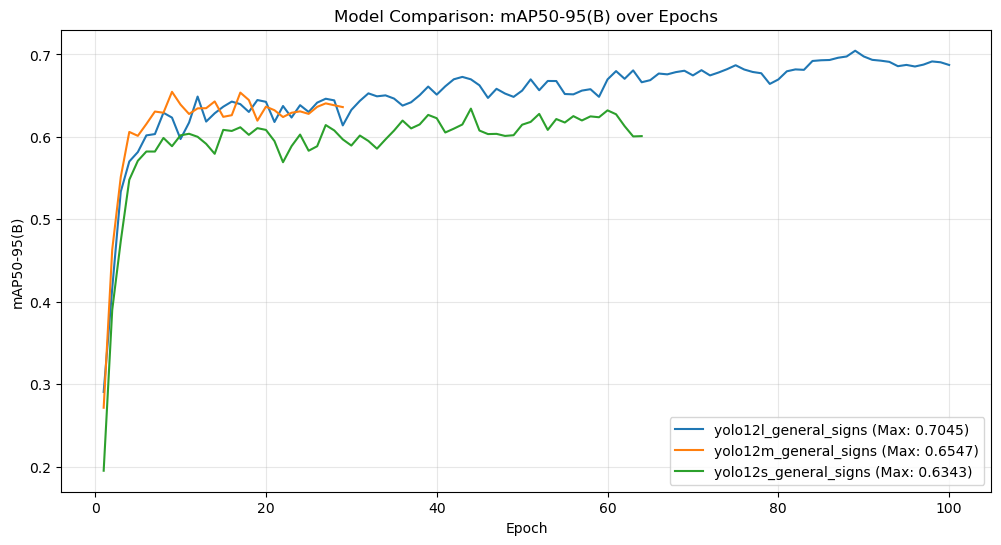


Best Model Performance Summary:
                Model  Best mAP50-95  Best mAP50  Epoch
yolo12l_general_signs        0.70451     0.81720     89
yolo12m_general_signs        0.65467     0.79473      9
yolo12s_general_signs        0.63428     0.77049     44


In [ ]:
plt.figure(figsize=(12, 6))

best_results = []

modelfilenames = [name for name in os.listdir('runs') if name.startswith('yolo') and not name.endswith('augmented') and os.path.isdir(os.path.join('runs', name))]

for model_name in modelfilenames:
    results_path = os.path.join('runs', model_name, 'results.csv')
    
    if os.path.exists(results_path):
        # Read the results file
        try:
            df = pd.read_csv(results_path)
            
            # Clean column names (remove extra spaces)
            df.columns = df.columns.str.strip()
            
            # Get the mAP50-95 metric
            map_col = 'metrics/mAP50-95(B)'
            
            if map_col in df.columns:
                # Plot
                plt.plot(df['epoch'], df[map_col], label=f'{model_name} (Max: {df[map_col].max():.4f})')
                
                # Store best result
                best_results.append({
                    'Model': model_name,
                    'Best mAP50-95': df[map_col].max(),
                    'Best mAP50': df['metrics/mAP50(B)'].max() if 'metrics/mAP50(B)' in df.columns else None,
                    'Epoch': df.loc[df[map_col].idxmax(), 'epoch']
                })
        except Exception as e:
            print(f"Error reading {results_path}: {e}")
            
    else:
        print(f"Warning: No results found for {model_name} at {results_path}")

plt.title('Model Comparison: mAP50-95(B) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP50-95(B)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display summary table
if best_results:
    results_df = pd.DataFrame(best_results)
    results_df = results_df.sort_values(by='Best mAP50-95', ascending=False).reset_index(drop=True)
    print("\nBest Model Performance Summary:")
    print(results_df.to_string(index=False))

## 3. Data Augmented Training & Comparison

### i. Re-training with modified data-augmentation hyperparameters

In [30]:
for modelname in modelnames:
    
    # load model
    model = YOLO(f'{modelname}.pt')

    model.train(
        data=YOLO_YAML_PATH,
        epochs=100,                                         # default
        batch=-1,                                           # autobatch 60% gpu usage
        patience=20,                                        # early stopping after 20 epochs of no improvement
        device=0 if torch.cuda.is_available() else 'cpu',   # use GPU if available
        imgsz=640,                                          # default
        project='runs',
        task='detect',
        name=f'{modelname}_general_signs_augmented',        # folder name for results
        save_period=10,                                     # save every 10 epochs
        exist_ok=True,                                      # overwrite existing results
        
        # Data Augmentation hyperparameters
        fliplr=0.0,                                         # default 0.5
        flipud=0.0,                                         # default
        mosaic=1.0,                                         # default
        mixup=0.1,                                          # default 0.0
        degrees=10.0,                                       # default 0.0
        scale=0.5,                                          # default
    )
    
    # clean up memory
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

FileNotFoundError: [Errno 2] No such file or directory: 'yolo12l_general_signs.pt'

### ii. Compare Results

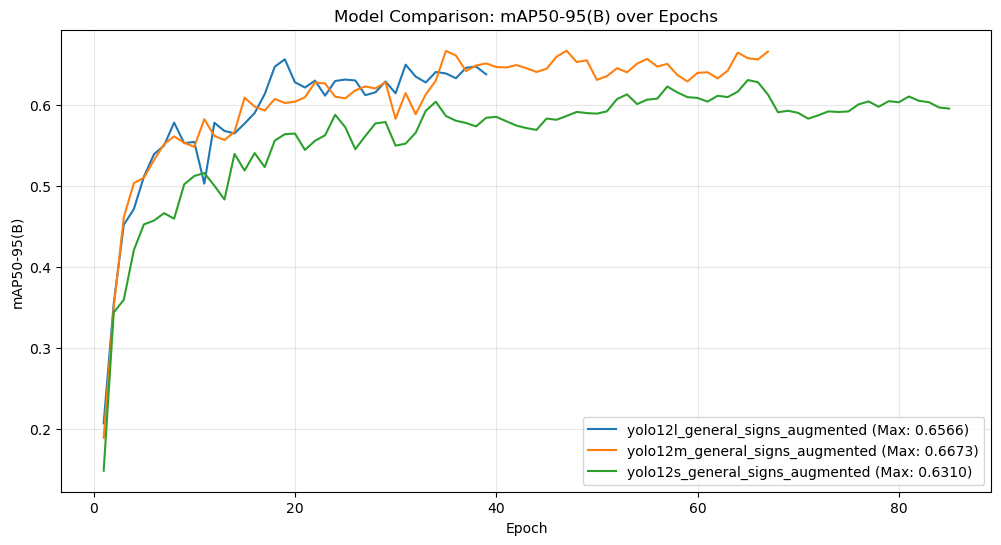


Best Model Performance Summary:
                          Model  Best mAP50-95  Best mAP50  Epoch
          yolo12l_general_signs        0.70451     0.81720     89
yolo12m_general_signs_augmented        0.66728     0.82091     47
yolo12m_general_signs_augmented        0.66728     0.82091     47
yolo12l_general_signs_augmented        0.65665     0.82993     19
yolo12l_general_signs_augmented        0.65665     0.82993     19
          yolo12m_general_signs        0.65467     0.79473      9
          yolo12s_general_signs        0.63428     0.77049     44
yolo12s_general_signs_augmented        0.63103     0.77727     65
yolo12s_general_signs_augmented        0.63103     0.77727     65


In [ ]:
plt.figure(figsize=(12, 6))

modelfilenames = [name for name in os.listdir('runs') if name.startswith('yolo') and name.endswith('augmented') and os.path.isdir(os.path.join('runs', name))]

for model_name in modelfilenames:
    results_path = os.path.join('runs', model_name, 'results.csv')
    
    if os.path.exists(results_path):
        # Read the results file
        try:
            df = pd.read_csv(results_path)
            
            # Clean column names (remove extra spaces)
            df.columns = df.columns.str.strip()
            
            # Get the mAP50-95 metric
            map_col = 'metrics/mAP50-95(B)'
            
            if map_col in df.columns:
                # Plot
                plt.plot(df['epoch'], df[map_col], label=f'{model_name} (Max: {df[map_col].max():.4f})')
                
                # Store best result
                best_results.append({
                    'Model': model_name,
                    'Best mAP50-95': df[map_col].max(),
                    'Best mAP50': df['metrics/mAP50(B)'].max() if 'metrics/mAP50(B)' in df.columns else None,
                    'Epoch': df.loc[df[map_col].idxmax(), 'epoch']
                })
        except Exception as e:
            print(f"Error reading {results_path}: {e}")
            
    else:
        print(f"Warning: No results found for {model_name} at {results_path}")

plt.title('Model Comparison: mAP50-95(B) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP50-95(B)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display summary table
if best_results:
    results_df = pd.DataFrame(best_results)
    results_df = results_df.sort_values(by='Best mAP50-95', ascending=False).reset_index(drop=True)
    print("\nBest Model Performance Summary:")
    print(results_df.to_string(index=False))

### iii. Compare best data augmented with best default


--- Champion vs Champion Comparison ---
                          Model  Best mAP50-95  Best mAP50  Epoch
          yolo12l_general_signs        0.70451     0.81720     89
yolo12m_general_signs_augmented        0.66728     0.82091     47


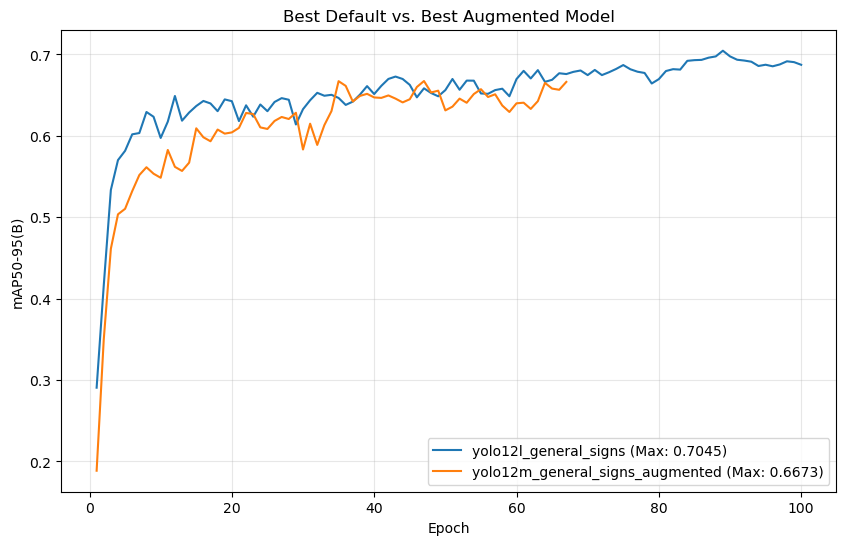

In [34]:
# find the best scoring models
best_default = max([r for r in best_results if 'augmented' not in r['Model']], key=lambda x: x['Best mAP50-95'])
best_augmented = max([r for r in best_results if 'augmented' in r['Model']], key=lambda x: x['Best mAP50-95'])

comparison_list = []
if best_default:
    comparison_list.append(best_default)
if best_augmented:
    comparison_list.append(best_augmented)

if comparison_list:
    # Create DataFrame for display
    comp_df = pd.DataFrame(comparison_list)
    
    # Reorder columns if needed for clarity
    cols = ['Model', 'Best mAP50-95', 'Best mAP50', 'Epoch']
    # Filter only columns that exist in the dataframe
    cols = [c for c in cols if c in comp_df.columns]
    comp_df = comp_df[cols]
    
    print("\n--- Champion vs Champion Comparison ---")
    print(comp_df.to_string(index=False))
    
    # Plotting the comparison
    plt.figure(figsize=(10, 6))
    
    for model_info in comparison_list:
        model_name = model_info['Model']
        results_path = os.path.join('runs', model_name, 'results.csv')
        
        if os.path.exists(results_path):
            try:
                df = pd.read_csv(results_path)
                df.columns = df.columns.str.strip()
                map_col = 'metrics/mAP50-95(B)'
                
                if map_col in df.columns:
                    plt.plot(df['epoch'], df[map_col], label=f"{model_name} (Max: {model_info['Best mAP50-95']:.4f})")
            except Exception as e:
                print(f"Error reading {results_path}: {e}")

    plt.title('Best Default vs. Best Augmented Model')
    plt.xlabel('Epoch')
    plt.ylabel('mAP50-95(B)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("Insufficient data to compare default vs augmented models.")